In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.models as models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
data_dir = "Dataset"

classes = os.listdir(data_dir)
data = []
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for file in os.listdir(cls_path):
        data.append([file, cls])

df = pd.DataFrame(data, columns=["file", "label"])
df.head()

,file,label
0,00002_id00062_wavtolip.mp4,FakeVideo-FakeAudio
1,00002_id00145_wavtolip.mp4,FakeVideo-FakeAudio
2,00002_id00184_WaTN0ry04Qs_id04073_wavtolip.mp4,FakeVideo-FakeAudio
3,00002_id00261_wavtolip.mp4,FakeVideo-FakeAudio
4,00002_id00272_VLY1boTtbRM_id03605_wavtolip.mp4,FakeVideo-FakeAudio


In [3]:
print("\nClass Distribution:\n", df['label'].value_counts())


Class Distribution:
 label
FakeVideo-RealAudio    3037
FakeVideo-FakeAudio    1345
RealVideo-FakeAudio     179
RealVideo-RealAudio     178
Name: count, dtype: int64


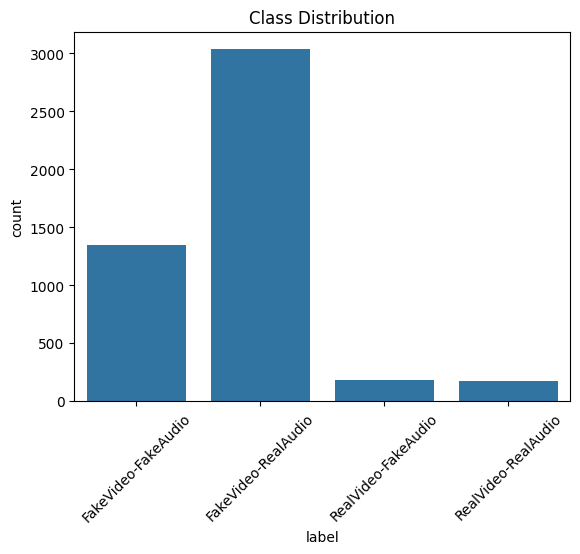

In [4]:
sns.countplot(x='label', data=df)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

# Video Frame Extraction

In [5]:
import cv2
import numpy as np

def extract_frames(video_path, max_frames=30):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total // max_frames)

    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = frame / 255.0
            frames.append(frame)

        count += 1

    cap.release()

    while len(frames) < max_frames:
        frames.append(np.zeros((224,224,3)))

    return np.array(frames[:max_frames])

# Audio Extraction (Mel Spectrogram)

In [6]:
import moviepy.editor as mp
import librosa

def extract_audio_features(video_path):
    clip = mp.VideoFileClip(video_path)
    audio = clip.audio.to_soundarray(fps=16000)
    
    if len(audio.shape) > 1:
        audio = audio.mean(axis=1)

    mel = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=128)
    mel_db = librosa.power_to_db(mel)

    mel_db = np.resize(mel_db, (128, 128))
    return mel_db

# Dataset Loader

In [7]:
# Before splitting
labels = sorted(df['label'].unique())
label_map = {label:i for i,label in enumerate(labels)}

print(label_map)

{'FakeVideo-FakeAudio': 0, 'FakeVideo-RealAudio': 1, 'RealVideo-FakeAudio': 2, 'RealVideo-RealAudio': 3}


In [8]:
class DeepFakeDataset(torch.utils.data.Dataset):
    def __init__(self, df, root_dir, label_map):
        self.df = df
        self.root = root_dir
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file, label = self.df.iloc[idx]
        path = os.path.join(self.root, label, file)

        video = extract_frames(path)
        audio = extract_audio_features(path)

        video = torch.tensor(video).permute(0,3,1,2).float()
        audio = torch.tensor(audio).unsqueeze(0).float()

        return video, audio, self.label_map[label]

In [9]:
df

,file,label
0,00002_id00062_wavtolip.mp4,FakeVideo-FakeAudio
1,00002_id00145_wavtolip.mp4,FakeVideo-FakeAudio
2,00002_id00184_WaTN0ry04Qs_id04073_wavtolip.mp4,FakeVideo-FakeAudio
3,00002_id00261_wavtolip.mp4,FakeVideo-FakeAudio
4,00002_id00272_VLY1boTtbRM_id03605_wavtolip.mp4,FakeVideo-FakeAudio
...,...,...
4734,02561.mp4,RealVideo-RealAudio
4735,03168.mp4,RealVideo-RealAudio
4736,05479.mp4,RealVideo-RealAudio
4737,06152.mp4,RealVideo-RealAudio


In [10]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'])

train_dataset = DeepFakeDataset(train_df, data_dir, label_map)
test_dataset  = DeepFakeDataset(test_df, data_dir, label_map)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Lightweight CNN + Temporal Average Pooling Multimodal Network

In [11]:
class LightWeightModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Tiny Video CNN
        self.video_cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),  # 224 → 112
            nn.ReLU(),
            nn.MaxPool2d(2),                           # 112 → 56

            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 56 → 28
            nn.ReLU(),
            nn.MaxPool2d(2),                           # 28 → 14

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten()
        )

        self.video_fc = nn.Linear(64, 128)

        # Tiny Audio CNN
        self.audio_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten()
        )

        self.audio_fc = nn.Linear(16 * 4 * 4, 64)

        # Fusion
        self.fc = nn.Sequential(
            nn.Linear(128 + 64, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, video, audio):
        B, T, C, H, W = video.shape

        # Process frames
        video = video.view(B*T, C, H, W)
        feats = self.video_cnn(video)      # (B*T, 64)
        feats = self.video_fc(feats)       # (B*T, 128)

        feats = feats.view(B, T, -1)
        video_feat = feats.mean(dim=1)     # temporal avg

        # Audio
        audio_feat = self.audio_cnn(audio)
        audio_feat = self.audio_fc(audio_feat)

        combined = torch.cat([video_feat, audio_feat], dim=1)

        return self.fc(combined)

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LightWeightModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [13]:
best_val_acc = 0.0 

for epoch in range(3):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for video, audio, label in loop:
        video, audio, label = video.to(device), audio.to(device), label.to(device)

        optimizer.zero_grad()
        outputs = model(video, audio)
        loss = criterion(outputs, label)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == label).sum().item()
        total += label.size(0)
        acc = correct / total

        loop.set_postfix(loss=loss.item(), acc=acc)

    train_acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")

    # ================= VALIDATION =================
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for video, audio, label in test_loader:
            video, audio, label = video.to(device), audio.to(device), label.to(device)

            outputs = model(video, audio)
            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == label).sum().item()
            val_total += label.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save (model.state_dict(), "Model/LightWeightModel_best.pth")
        print(f" Best model saved with accuracy: {best_val_acc:.4f}")

Epoch 1: 100%|████████████████████████████████████████████████| 237/237 [15:43<00:00,  3.98s/it, acc=0.652, loss=0.677]
Epoch 1, Loss: 0.9107, Train Acc: 0.6518
Validation Accuracy: 0.6540
 Best model saved with accuracy: 0.6540
Epoch 2: 100%|█████████████████████████████████████████████████| 237/237 [15:03<00:00,  3.81s/it, acc=0.714, loss=1.09]
Epoch 2, Loss: 0.7673, Train Acc: 0.7135
Validation Accuracy: 0.7616
 Best model saved with accuracy: 0.7616
Epoch 3: 100%|████████████████████████████████████████████████| 237/237 [15:05<00:00,  3.82s/it, acc=0.749, loss=0.616]
Epoch 3, Loss: 0.6864, Train Acc: 0.7486
Validation Accuracy: 0.7732
 Best model saved with accuracy: 0.7732


Model loaded successfully!

 Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.58      0.65       269
           1       0.78      0.95      0.86       607
           2       0.00      0.00      0.00        36
           3       0.00      0.00      0.00        36

    accuracy                           0.77       948
   macro avg       0.38      0.38      0.38       948
weighted avg       0.71      0.77      0.73       948


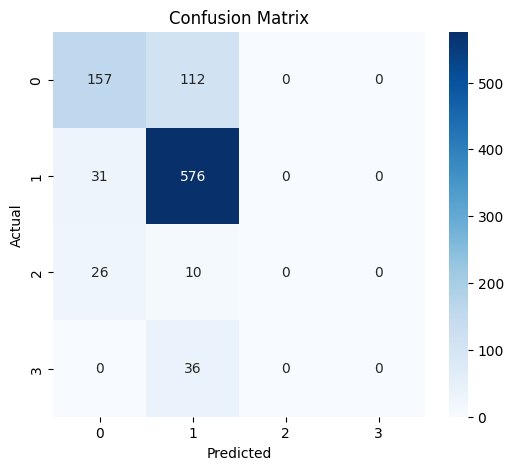

In [14]:
model.load_state_dict(torch.load("Model/LightWeightModel_best.pth", map_location=device))
model.eval()

print(" Model loaded successfully!")

y_true = []
y_pred = []

with torch.no_grad():
    for video, audio, label in test_loader:
        video = video.to(device)
        audio = audio.to(device)

        outputs = model(video, audio)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(label.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

#  CLASSIFICATION REPORT 
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred))

#  CONFUSION MATRIX 
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


 Metrics:
Accuracy  : 0.7732
Precision : 0.7106
Recall    : 0.7732
F1 Score  : 0.7345


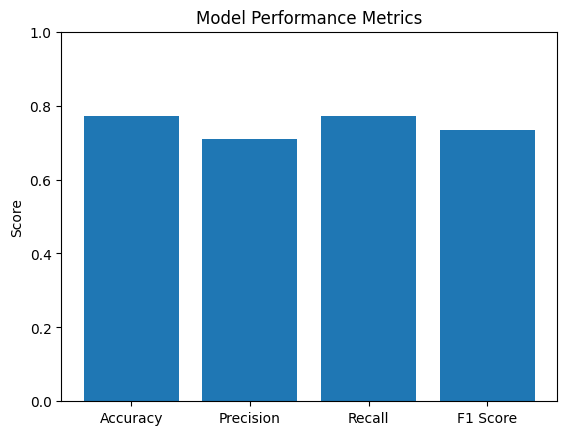

In [15]:
liw_acc = accuracy_score(y_true, y_pred)
liw_prec = precision_score(y_true, y_pred, average='weighted')
liw_rec = recall_score(y_true, y_pred, average='weighted')
liw_f1 = f1_score(y_true, y_pred, average='weighted')

print("\n Metrics:")
print(f"Accuracy  : {liw_acc:.4f}")
print(f"Precision : {liw_prec:.4f}")
print(f"Recall    : {liw_rec:.4f}")
print(f"F1 Score  : {liw_f1:.4f}")


#  METRICS GRAPH 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [liw_acc, liw_prec, liw_rec, liw_f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

# ResNet18 + LSTM Multimodal Fusion Network

In [16]:
class MultiModalModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Video backbone
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()

        self.lstm = nn.LSTM(512, 256, batch_first=True)

        # Audio CNN
        self.audio_cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten()
        )

        self.audio_fc = nn.Linear(64 * 32 * 32, 256)

        # Fusion
        self.fc = nn.Sequential(
            nn.Linear(256 + 256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, video, audio):
        B, T, C, H, W = video.shape

        video = video.view(B*T, C, H, W)
        feats = self.cnn(video)
        feats = feats.view(B, T, -1)

        _, (h, _) = self.lstm(feats)
        video_feat = h[-1]

        audio_feat = self.audio_cnn(audio)
        audio_feat = self.audio_fc(audio_feat)

        combined = torch.cat([video_feat, audio_feat], dim=1)

        return self.fc(combined)

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiModalModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [18]:
best_val_acc = 0.0 

for epoch in range(3):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for video, audio, label in loop:
        video, audio, label = video.to(device), audio.to(device), label.to(device)

        optimizer.zero_grad()
        outputs = model(video, audio)
        loss = criterion(outputs, label)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == label).sum().item()
        total += label.size(0)
        acc = correct / total

        loop.set_postfix(loss=loss.item(), acc=acc)

    train_acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")

    # ================= VALIDATION =================
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for video, audio, label in test_loader:
            video, audio, label = video.to(device), audio.to(device), label.to(device)

            outputs = model(video, audio)
            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == label).sum().item()
            val_total += label.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "Model/best_model.pth")
        print(f" Best model saved with accuracy: {best_val_acc:.4f}")

Epoch 1: 100%|████████████████████████████████████████████████| 237/237 [17:05<00:00,  4.33s/it, acc=0.826, loss=0.304]
Epoch 1, Loss: 1.2159, Train Acc: 0.8264
Validation Accuracy: 0.9473
 Best model saved with accuracy: 0.9473
Epoch 2: 100%|███████████████████████████████████████████████| 237/237 [16:38<00:00,  4.21s/it, acc=0.971, loss=0.0541]
Epoch 2, Loss: 0.0967, Train Acc: 0.9712
Validation Accuracy: 0.9599
 Best model saved with accuracy: 0.9599
Epoch 3: 100%|███████████████████████████████████████████████| 237/237 [16:41<00:00,  4.23s/it, acc=0.992, loss=0.0478]
Epoch 3, Loss: 0.0347, Train Acc: 0.9918
Validation Accuracy: 0.9430


Model loaded successfully!

 Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       269
           1       0.99      0.98      0.98       607
           2       1.00      0.97      0.99        36
           3       0.97      0.78      0.86        36

    accuracy                           0.98       948
   macro avg       0.98      0.93      0.95       948
weighted avg       0.98      0.98      0.98       948


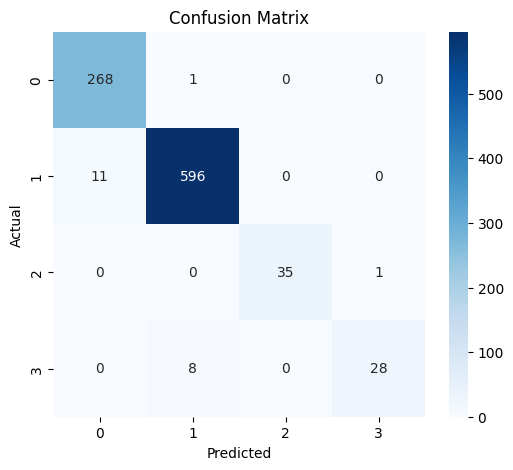

In [19]:
model.load_state_dict(torch.load("Model/best_model.pth", map_location=device))
model.eval()

print(" Model loaded successfully!")

y_true = []
y_pred = []

with torch.no_grad():
    for video, audio, label in test_loader:
        video = video.to(device)
        audio = audio.to(device)

        outputs = model(video, audio)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(label.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

#  CLASSIFICATION REPORT 
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred))

#  CONFUSION MATRIX 
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


 Metrics:
Accuracy  : 0.9778
Precision : 0.9780
Recall    : 0.9778
F1 Score  : 0.9774


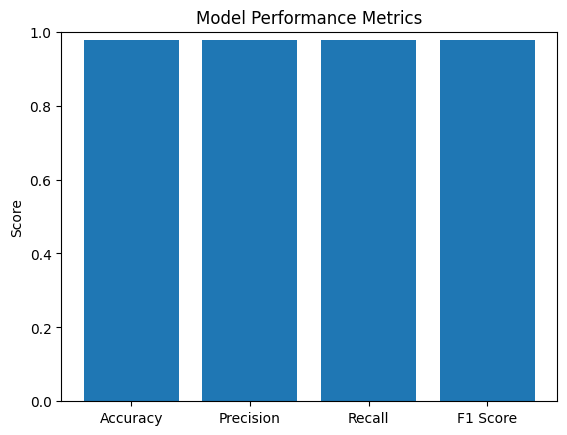

In [20]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")


#  METRICS GRAPH 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [acc, prec, rec, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

In [24]:
# Create comparison table
data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "LiteCNN-TAP-MM": [liw_acc, liw_prec, liw_rec, liw_f1],
    "ResNet18-LSTM-MM": [acc, prec, rec, f1]
}

result = pd.DataFrame(data)
result

,Metric,LiteCNN-TAP-MM,ResNet18-LSTM-MM
0,Accuracy,0.7732,0.9778
1,Precision,0.7106,0.9780
2,Recall,0.7732,0.9778
3,F1 Score,0.7345,0.9774


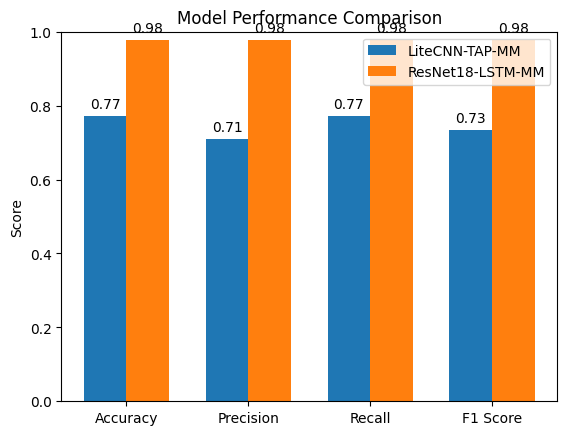

In [26]:
labels = data["Metric"]

model1 = data["LiteCNN-TAP-MM"]
model2 = data["ResNet18-LSTM-MM"]

x = np.arange(len(labels))
width = 0.35

plt.figure()

# FIX: correct bar positions (model1 left, model2 right)
bars1 = plt.bar(x - width/2, model1, width, label="LiteCNN-TAP-MM")
bars2 = plt.bar(x + width/2, model2, width, label="ResNet18-LSTM-MM")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

# FIX: correct annotation alignment
for i, v in enumerate(model1):
    plt.text(x[i] - width/2, v + 0.02, f"{v:.2f}", ha='center')

for i, v in enumerate(model2):
    plt.text(x[i] + width/2, v + 0.02, f"{v:.2f}", ha='center')

plt.show()